In [3]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

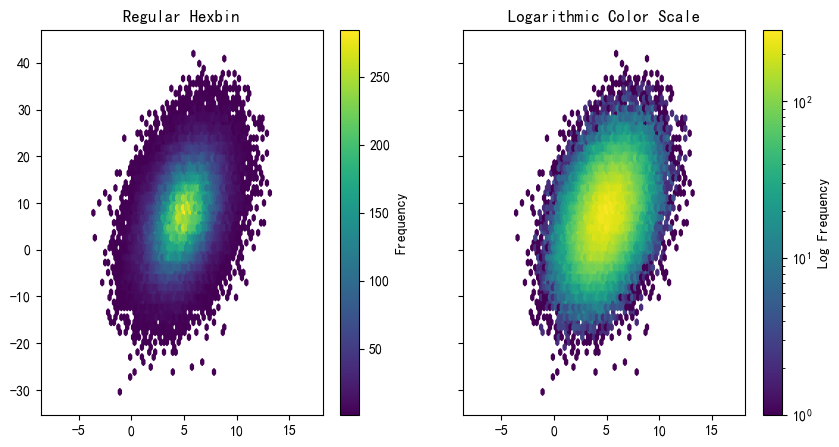

In [5]:
# 设置随机种子以确保结果可重复
np.random.seed(20230901)

# 生成数据
num_points = 80_000
x = np.random.normal(loc=5.0, scale=2.0, size=num_points)  # 使用正态分布生成x数据
y = 1.5 * x + 2.5 * np.random.normal(loc=0, scale=3.0, size=num_points)  # 线性关系生成y数据
xlim = (x.min() - 5, x.max() + 5)
ylim = (y.min() - 5, y.max() + 5)

# 创建图形和子图
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(10, 5))

# 绘制普通的六边形热图
hb1 = ax1.hexbin(x, y, gridsize=60, cmap='viridis', mincnt=1)
ax1.set(xlim=xlim, ylim=ylim)
ax1.set_title("Regular Hexbin")
cb1 = fig.colorbar(hb1, ax=ax1, label='Frequency')

# 绘制对数颜色尺度的六边形热图
hb2 = ax2.hexbin(x, y, gridsize=60, bins='log', cmap='viridis', mincnt=1)
ax2.set(xlim=xlim, ylim=ylim)
ax2.set_title("Logarithmic Color Scale")
cb2 = fig.colorbar(hb2, ax=ax2, label='Log Frequency')

# 显示图形
plt.show()


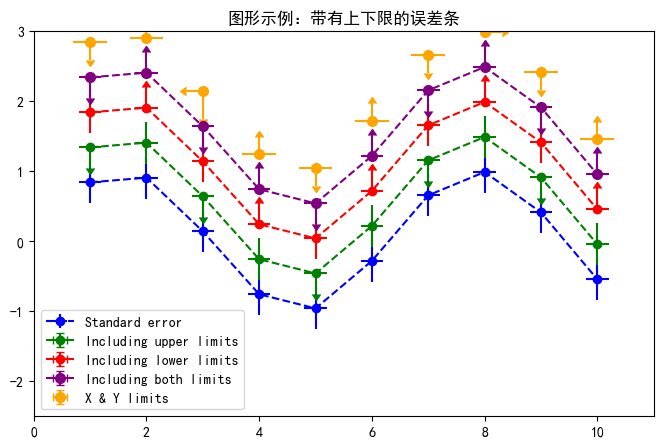

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 数据生成
x = np.linspace(1, 10, 10)  # 使用均匀分布的数据点
y = np.sin(x)  # 使用正弦函数生成y数据
xerr = 0.2  # x方向的误差
yerr = 0.3  # y方向的误差

# 定义误差条的下限和上限
low_lim = np.array([False, True, False, True, False, True, False, True, False, True])
up_lim = np.array([True, False, True, False, True, False, True, False, True, False])

# 绘制图形
fig, ax = plt.subplots(figsize=(8, 5))

# 绘制带有标准误差的误差条
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', linestyle='--', color='blue', label='Standard error')

# 绘制包含上限的误差条
ax.errorbar(x, y + 0.5, xerr=xerr, yerr=yerr, uplims=up_lim,
            fmt='o', linestyle='--', color='green', label='Including upper limits')

# 绘制包含下限的误差条
ax.errorbar(x, y + 1.0, xerr=xerr, yerr=yerr, lolims=low_lim,
            fmt='o', linestyle='--', color='red', label='Including lower limits')

# 绘制包含上下限的误差条
ax.errorbar(x, y + 1.5, xerr=xerr, yerr=yerr,
            lolims=low_lim, uplims=up_lim,
            fmt='o', markersize=7, linestyle='--', color='purple', label='Including both limits')

# 模拟 x 和 y 方向的上下限
xerr = 0.3
yerr = np.full_like(x, 0.25)
yerr[[2, 7]] = 0.4

# 模拟 x 方向的上下限
xlolims = np.zeros_like(x, dtype=bool)
xuplims = np.zeros_like(x, dtype=bool)
xlolims[[7]] = True  # 仅在这个索引处有限制
xuplims[[2]] = True  # 仅在这个索引处有限制

# 绘制带有x和y方向上下限的误差条
ax.errorbar(x, y + 2.0, xerr=xerr, yerr=yerr,
            xlolims=xlolims, xuplims=xuplims,
            uplims=up_lim, lolims=low_lim,
            fmt='o', markersize=7, color='orange', linestyle='none', label='X & Y limits')

# 设置图形属性
ax.set_xlim((0, 11))
ax.set_ylim((-2.5, 3.0))
ax.set_title('图形示例：带有上下限的误差条')
ax.legend()

# 显示图形
plt.show()


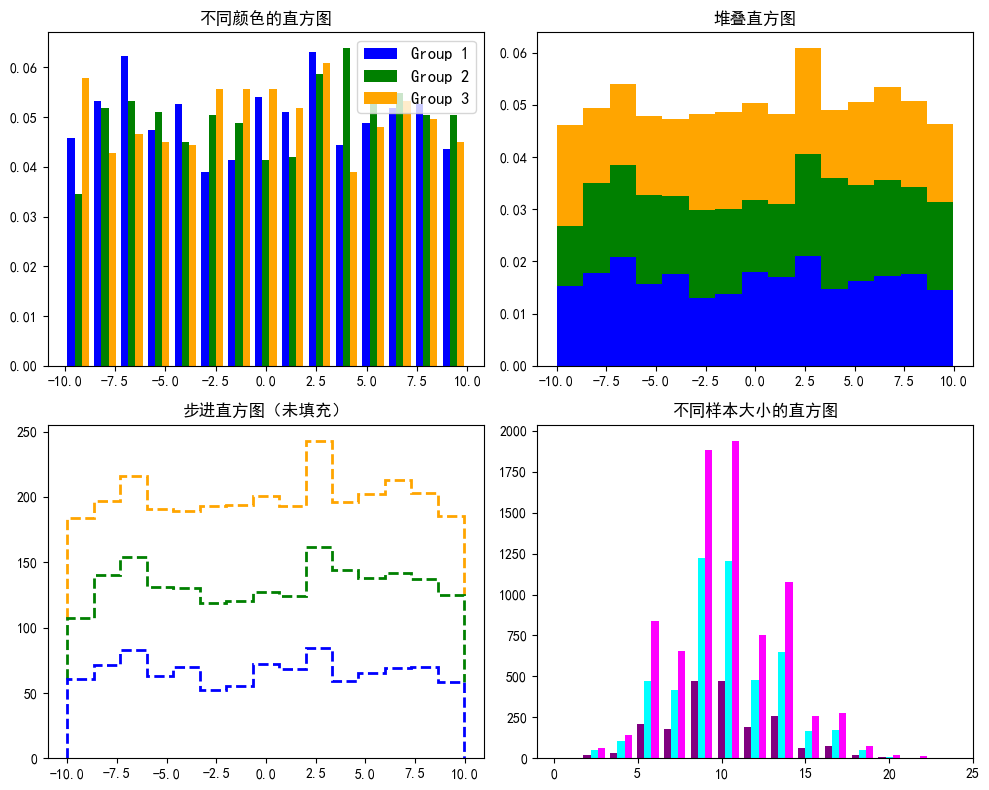

In [9]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(202309)

# 数据生成
n_bins = 15
x = [np.random.uniform(low=-10, high=10, size=1000) for _ in range(3)]

# 创建一个2x2的子图
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# 定义颜色
colors = ['blue', 'green', 'orange']

# 直方图1: 每组数据用不同颜色显示，并加上图例
ax0.hist(x, n_bins, density=True, histtype='bar', color=colors, label=['Group 1', 'Group 2', 'Group 3'])
ax0.legend(prop={'size': 12})
ax0.set_title('不同颜色的直方图')

# 直方图2: 堆叠直方图
ax1.hist(x, n_bins, density=True, histtype='bar', stacked=True, color=colors)
ax1.set_title('堆叠直方图')

# 直方图3: 步进直方图（未填充）
ax2.hist(x, n_bins, histtype='step', stacked=True, color=colors, linestyle='--', linewidth=2)
ax2.set_title('步进直方图（未填充）')

# 创建不同长度的数据集
x_multi = [np.random.poisson(lam=10, size=n) for n in [2000, 5000, 8000]]
ax3.hist(x_multi, n_bins, histtype='bar', color=['purple', 'cyan', 'magenta'])
ax3.set_title('不同样本大小的直方图')

# 调整子图布局
fig.tight_layout()
plt.show()


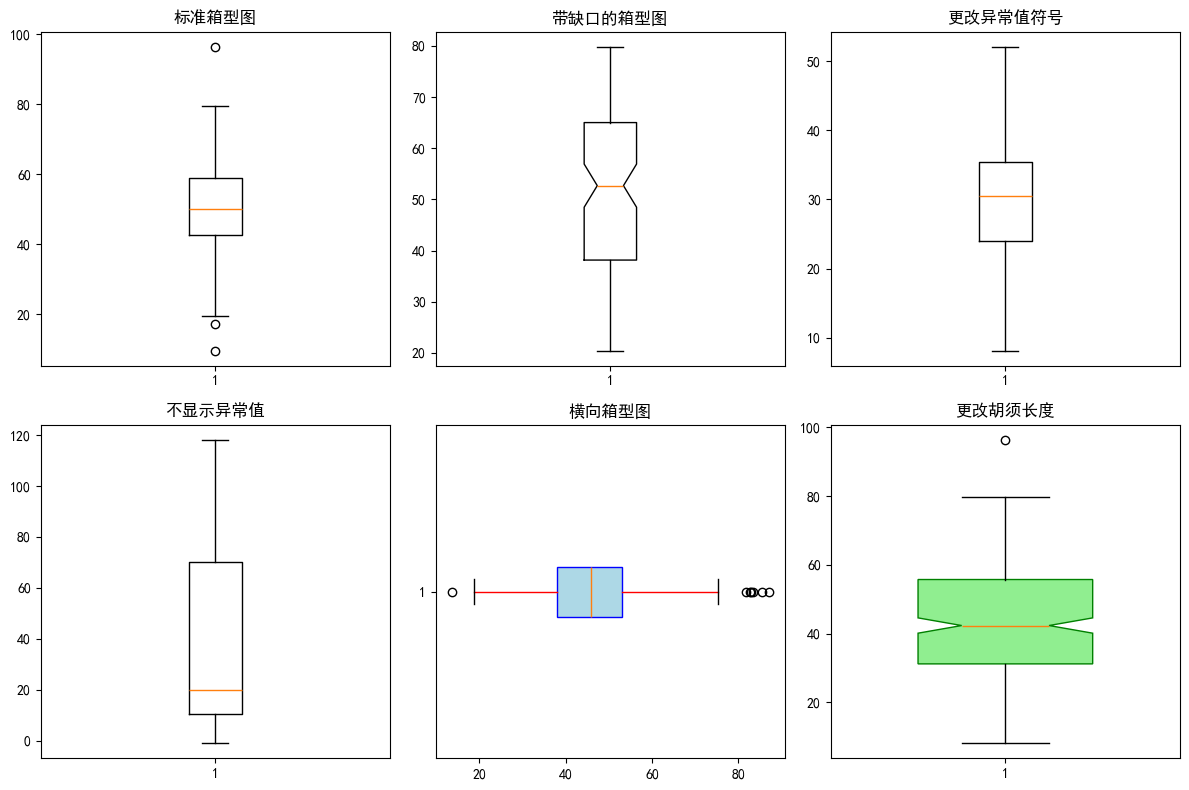

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以确保结果可复现
np.random.seed(202309)

# 生成不同的模拟数据
data1 = np.random.normal(loc=50, scale=15, size=100)  # 正态分布数据
data2 = np.random.uniform(low=20, high=80, size=100)  # 均匀分布数据
data3 = np.random.normal(loc=30, scale=10, size=100)
data4 = np.concatenate([np.random.normal(loc=70, scale=20, size=50),
                          np.random.normal(loc=10, scale=5, size=50)])
data5 = np.concatenate([np.random.normal(loc=50, scale=15, size=80),
                          np.random.normal(loc=40, scale=10, size=20)])
data6 = np.concatenate([data1, data2, data3])

# 创建一个2x3的子图
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# 标准箱型图
axs[0, 0].boxplot(data1)
axs[0, 0].set_title('标准箱型图')

# 箱型图带缺口
axs[0, 1].boxplot(data2, notch=True)
axs[0, 1].set_title('带缺口的箱型图')

# 更改异常值点的符号
axs[0, 2].boxplot(data3, flierprops=dict(marker='o', color='purple', markersize=7))
axs[0, 2].set_title('更改异常值符号')

# 不显示异常值点
axs[1, 0].boxplot(data4, showfliers=False)
axs[1, 0].set_title('不显示异常值')

# 横向箱型图
axs[1, 1].boxplot(data5, vert=False, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', color='blue'),
                  whiskerprops=dict(color='red'))
axs[1, 1].set_title('横向箱型图')

# 更改胡须长度
axs[1, 2].boxplot(data6, widths=0.5, notch=True, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', color='green'),
                  whiskerprops=dict(color='black'))
axs[1, 2].set_title('更改胡须长度')

# 调整图形布局
fig.tight_layout()
plt.show()


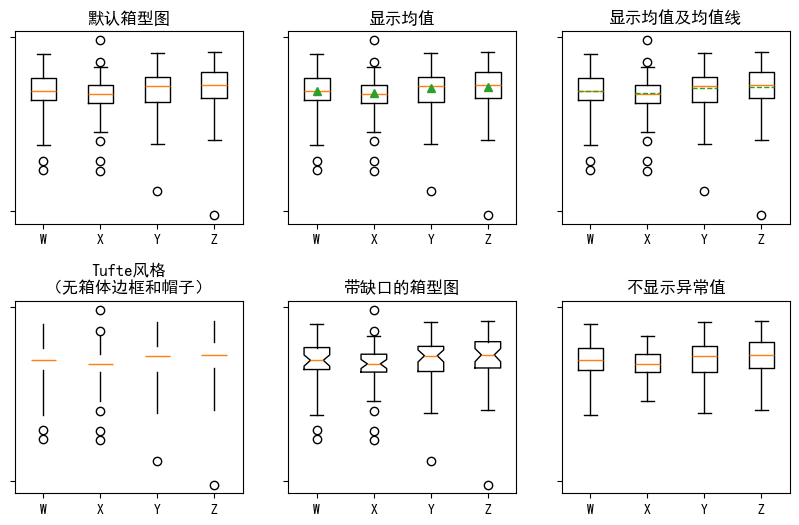

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 生成数据
np.random.seed(202309)
data = np.random.normal(loc=50, scale=15, size=(40, 4))
labels = ['W', 'X', 'Y', 'Z']
fontsize = 12  # 设置字体大小

# 创建子图
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 6), sharey=True)

# 默认箱型图
axs[0, 0].boxplot(data, labels=labels)
axs[0, 0].set_title('默认箱型图', fontsize=fontsize)

# 显示均值
axs[0, 1].boxplot(data, labels=labels, showmeans=True)
axs[0, 1].set_title('显示均值', fontsize=fontsize)

# 显示均值并绘制均值线
axs[0, 2].boxplot(data, labels=labels, showmeans=True, meanline=True)
axs[0, 2].set_title('显示均值及均值线', fontsize=fontsize)

# Tufte风格（不显示箱体边框和帽子）
axs[1, 0].boxplot(data, labels=labels, showbox=False, showcaps=False)
axs[1, 0].set_title('Tufte风格\n（无箱体边框和帽子）', fontsize=fontsize)

# 带缺口的箱型图，bootstrap选项已弃用
axs[1, 1].boxplot(data, labels=labels, notch=True)
axs[1, 1].set_title('带缺口的箱型图', fontsize=fontsize)

# 不显示异常值
axs[1, 2].boxplot(data, labels=labels, showfliers=False)
axs[1, 2].set_title('不显示异常值', fontsize=fontsize)

# 设置y轴为对数尺度
for ax in axs.flat:
    ax.set_yscale('symlog')
    ax.set_yticklabels([])  # 隐藏y轴标签

# 调整子图间距
fig.subplots_adjust(hspace=0.4)
plt.show()


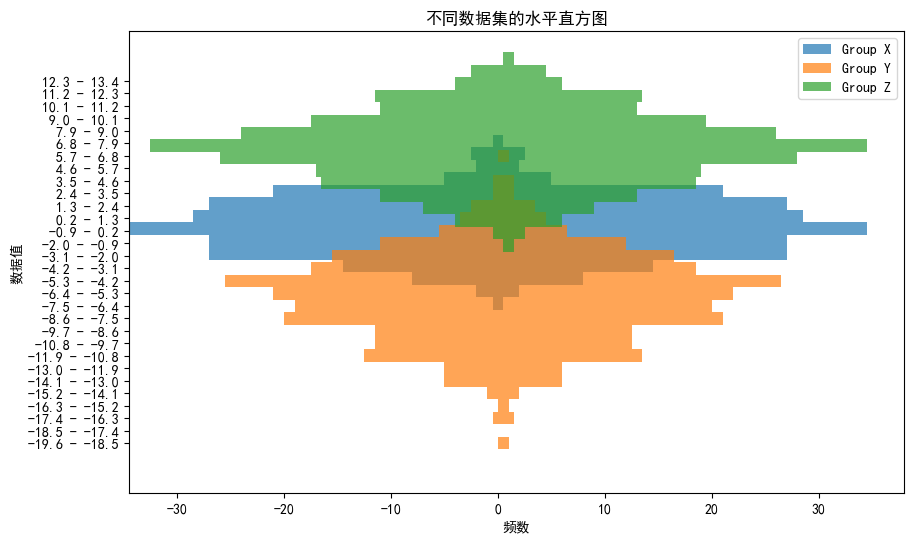

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以确保结果可重现
np.random.seed(41)

# 设置直方图的参数
num_bins = 30  # 直方图的箱数
num_points = 400  # 每组数据点数
labels = ["Group X", "Group Y", "Group Z"]  # 标签
data_sets = [
    np.random.normal(loc=2.0, scale=2.5, size=num_points),  
    np.random.normal(loc=-6, scale=4.0, size=num_points),   
    np.random.normal(loc=5.0, scale=3.0, size=num_points) 
]

# 计算绘图所需的量
hist_range = (min(np.min(d) for d in data_sets), max(np.max(d) for d in data_sets))
binned_data_sets = [np.histogram(d, bins=num_bins, range=hist_range)[0] for d in data_sets]

# 计算每组数据的最大值，用于设置条形图的位置
binned_max_vals = np.max(binned_data_sets, axis=1)
x_offsets = np.linspace(0, 1, len(binned_data_sets))  # 设置每组数据的横坐标偏移量

# 计算直方图的边缘和中心
bin_edges = np.linspace(hist_range[0], hist_range[1], num_bins + 1)
bin_width = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + bin_width / 2

# 绘制直方图
fig, ax = plt.subplots(figsize=(10, 6))
for i, (binned_data, x_offset) in enumerate(zip(binned_data_sets, x_offsets)):
    # 为每组数据设置条形图的起始位置
    left_edges = x_offset - binned_data / 2
    ax.barh(bin_centers + i * 2, binned_data, height=bin_width, left=left_edges, alpha=0.7, label=labels[i])

# 添加图例、标签和标题
ax.set_yticks(bin_centers + (len(data_sets) - 1) * 2 / 2)
ax.set_yticklabels([f'{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}' for i in range(num_bins)])
ax.set_xlabel("频数")
ax.set_ylabel("数据值")
ax.set_title("不同数据集的水平直方图")
ax.legend()

plt.show()


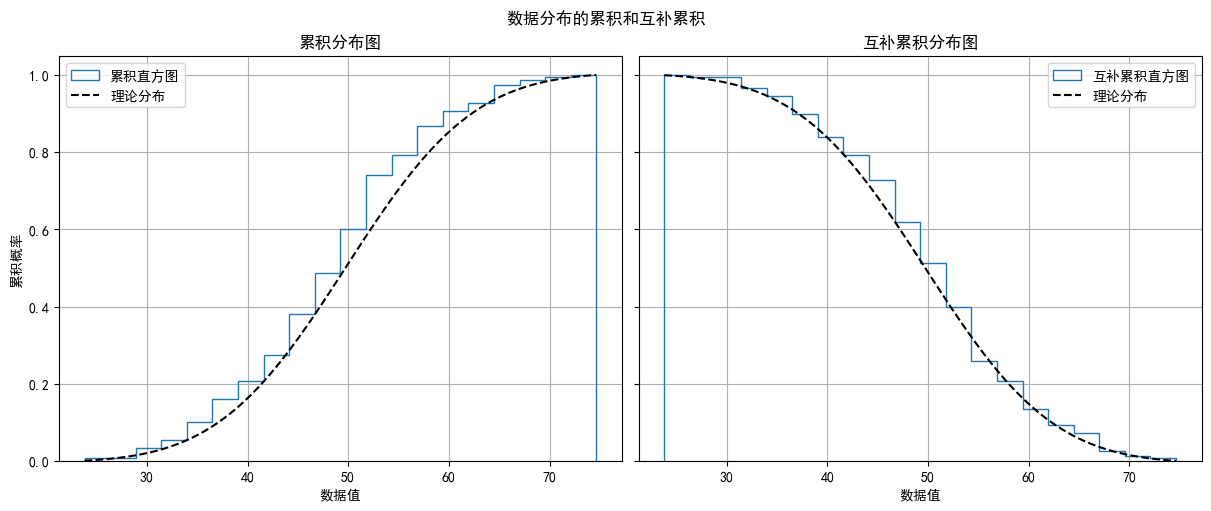

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以确保结果可重现
np.random.seed(42)

# 生成数据
mean = 50
std_dev = 10
num_bins = 20
data = np.random.normal(mean, std_dev, size=150)

# 创建一个具有两个子图的图形
fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 累积分布图
axs[0].hist(data, bins=num_bins, density=True, histtype='step', cumulative=True, label='累积直方图')
axs[0].set_title('累积分布图')
axs[0].set_xlabel('数据值')
axs[0].set_ylabel('累积概率')

# 计算理论累积分布
x = np.linspace(data.min(), data.max(), 100)
y = ((1 / (np.sqrt(2 * np.pi) * std_dev)) *
     np.exp(-0.5 * ((x - mean) / std_dev) ** 2))
y = np.cumsum(y) * (x[1] - x[0])
y /= y[-1]
axs[0].plot(x, y, 'k--', linewidth=1.5, label='理论分布')
axs[0].legend()

# 互补累积分布图
axs[1].hist(data, bins=num_bins, density=True, histtype='step', cumulative=-1, label='互补累积直方图')
axs[1].set_title('互补累积分布图')
axs[1].set_xlabel('数据值')
axs[1].set_ylabel('概率密度')

# 计算理论互补累积分布
axs[1].plot(x, 1 - y, 'k--', linewidth=1.5, label='理论分布')
axs[1].legend()

# 添加网格和外部标签
for ax in axs:
    ax.grid(True)
    ax.label_outer()

# 设置图形标题
fig.suptitle('数据分布的累积和互补累积')

plt.show()


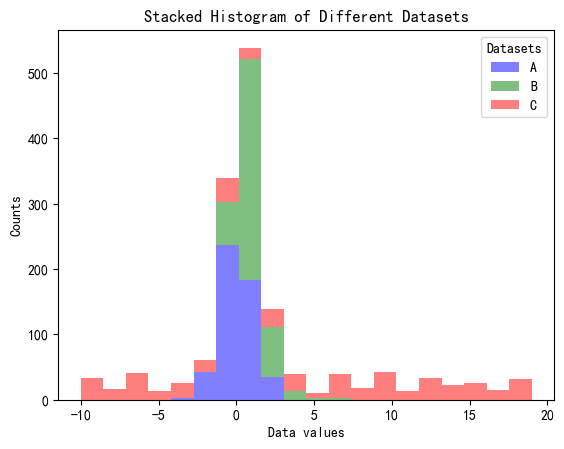

In [49]:
import matplotlib.pyplot as plt  
import numpy as np  
  
np.random.seed(19680801)  
  
# 设置数据点数量和类别标签  
number_of_data_points = 500  
labels = ['A', 'B', 'C']  
  
# 生成三个不同分布的数据集  
data_sets = [  
    np.random.normal(0, 1, number_of_data_points),  # 第一个数据集，正态分布  
    np.random.exponential(scale=1, size=number_of_data_points),  # 第二个数据集，指数分布  
    np.random.randint(-10, 20, size=number_of_data_points)  # 第三个数据集，随机整数  
]  
  
# 设置柱状图的区间范围和bin数量  
number_of_bins = 20  
hist_range = (min(min(d) for d in data_sets), max(max(d) for d in data_sets))  
  
# 绘制堆叠柱状图  
fig, ax = plt.subplots()  
colors = ['b', 'g', 'r']  # 为三个数据集分配不同的颜色  
bottom = np.zeros(number_of_bins)  # 初始化底部位置  
  
for data, color in zip(data_sets, colors):  
    # 计算每个数据集的直方图  
    n, bins, patches = ax.hist(data, bins=number_of_bins, range=hist_range, bottom=bottom, alpha=0.5, color=color, label=labels.pop(0))  
    bottom += n  # 更新底部位置为当前柱状图的高度  
  
# 设置图表标签和标题  
ax.set_xlabel("Data values")  
ax.set_ylabel("Counts")  
ax.set_title("Stacked Histogram of Different Datasets")  
ax.legend(title="Datasets")  
  
plt.show()

透明度线图耗时: 0.319 秒
2D直方图绘制耗时: 0.118 秒


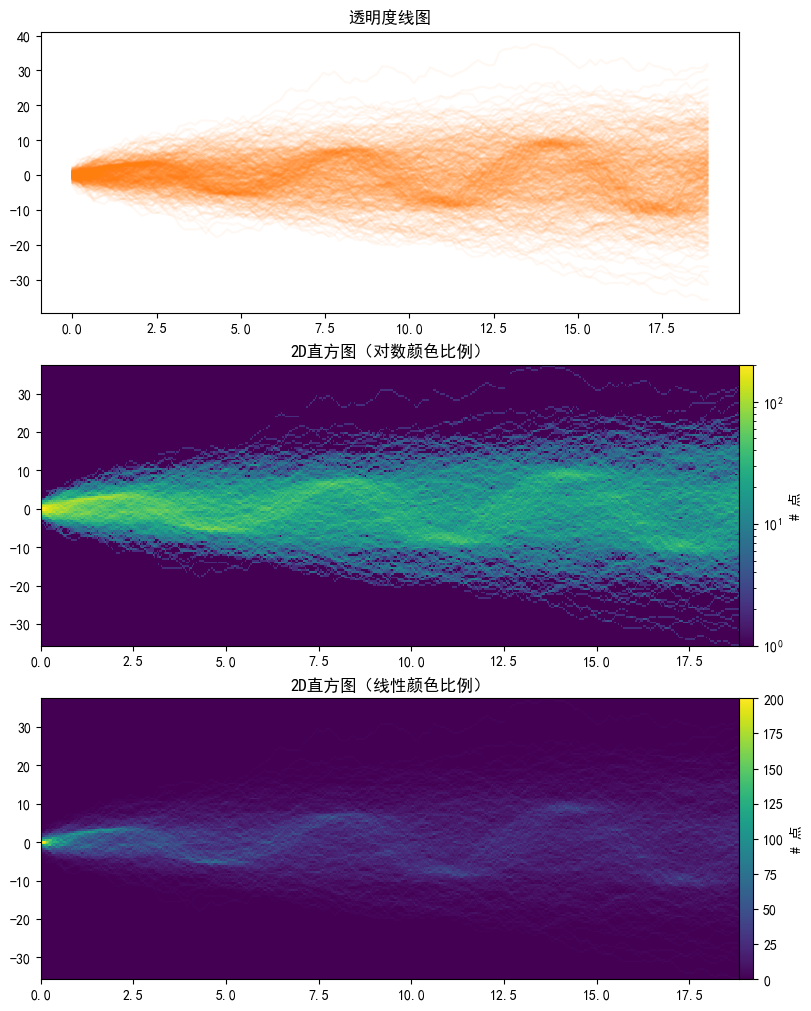

In [53]:
import time
import matplotlib.pyplot as plt
import numpy as np

# 创建图形及子图
fig, axes = plt.subplots(nrows=3, figsize=(8, 10), layout='constrained')

# 设置随机种子以确保结果可重现
np.random.seed(42)

# 生成数据：正弦波和随机噪声
num_series = 500
num_points = 120
SNR = 0.15  # 信噪比
x = np.linspace(0, 6 * np.pi, num_points)
# 生成无偏高斯随机游走
Y = np.cumsum(np.random.randn(num_series, num_points), axis=-1)
# 生成正弦信号
num_signal = round(SNR * num_series)
phi = (np.pi / 6) * np.random.randn(num_signal, 1)  # 较小的随机偏移
Y[-num_signal:] = (
    np.sqrt(np.arange(num_points))  # 随机游走RMS缩放因子
    * (np.sin(x - phi)
       + 0.1 * np.random.randn(num_signal, num_points))  # 增加的随机噪声
)

# 使用透明度绘制线图
tic = time.time()
axes[0].plot(x, Y.T, color="C1", alpha=0.05)
toc = time.time()
axes[0].set_title("透明度线图")
print(f"透明度线图耗时: {toc - tic:.3f} 秒")

# 将多时间序列转换为直方图
tic = time.time()
# 线性插值
num_fine = 1000
x_fine = np.linspace(x.min(), x.max(), num_fine)
y_fine = np.concatenate([np.interp(x_fine, x, y_row) for y_row in Y])
x_fine = np.broadcast_to(x_fine, (num_series, num_fine)).ravel()

# 绘制2D直方图（对数颜色比例）
cmap = plt.get_cmap("viridis")
cmap.set_bad(cmap(0))
hist2d, xedges, yedges = np.histogram2d(x_fine, y_fine, bins=[500, 150])
pcm = axes[1].pcolormesh(xedges, yedges, hist2d.T, cmap=cmap,
                         norm="log", vmax=200, rasterized=True)
fig.colorbar(pcm, ax=axes[1], label="# 点", pad=0)
axes[1].set_title("2D直方图（对数颜色比例）")

# 绘制2D直方图（线性颜色比例）
pcm = axes[2].pcolormesh(xedges, yedges, hist2d.T, cmap=cmap,
                         vmax=200, rasterized=True)
fig.colorbar(pcm, ax=axes[2], label="# 点", pad=0)
axes[2].set_title("2D直方图（线性颜色比例）")

toc = time.time()
print(f"2D直方图绘制耗时: {toc - tic:.3f} 秒")

plt.show()
